# DESMOSTRACIÓN DE SEGMENTACIÓN

En el presente cuaderno se hace una demostración de las segmetnaciones que efectúa el método ts-MULE (Schlegel et al. 2021) a las series de tiempo, para posteriormente efectuar la explicación usando los principios del método LIME (Ribeiro et al. 2016). Lo presentado acá se basa en los códigos disponibles en el repositorio de github del método ts-MULE, en https://github.com/visual-xai-for-time-series/ts-mule.

<u>Referencias:</u>
- Schlegel, U., Lam, D. V., Keim, D. A., & Seebacher, D. (2021). TS-MULE: Local Interpretable Model-Agnostic Explanations for Time Series Forecast Models. Joint European Conference on Machine Learning and Knowledge Discovery in Databases, 5–14. http://arxiv.org/abs/2109.08438
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). “Why should i trust you?” Explaining the predictions of any classifier. Proceedings of the ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 13-17-August-2016, 1135–1144. https://doi.org/10.1145/2939672.2939778

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 2]

import os
import sys
sys.path.insert(0, '../XAI_for_ts/ts-mule')

from tsmule.sampling.segment import MatrixProfileSegmentation, SAXSegmentation, WindowSegmentation
from tsmule.xai.viz import visualize_segmentation_mask

In [4]:
#Cargar datos
def load_pickle(p_name):
    with open(p_name, 'rb') as file:
        # Load the data from the file
        data = pickle.load(file)
    return data

data_path = 'DATA\\'
y_test = load_pickle(data_path+'ytest_new.pickle')
X_test = load_pickle(data_path+'xtest_new.pickle')
y_train = load_pickle(data_path+'ytrain_new.pickle')
X_train = load_pickle(data_path+'xtrain_new.pickle')
y_val = load_pickle(data_path+'yval_new.pickle')
X_val = load_pickle(data_path+'xval_new.pickle')

In [5]:
#Cargar modelo
import keras
from keras.models import load_model

model = load_model('MODELS\\transfer_learned_tsunami_classifier3.keras')

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
# x_nuevo tiene shape (n_steps, n_features) — la serie del evento actual
m = 1
x_nuevo = X_test[m:m+1]  # tu serie de tsunami en curso
X_nuevo = X_test[m]
model.predict(x_nuevo)
n = len(X_nuevo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


array([[0.99999976]], dtype=float32)

## Visualize Time Series

In [27]:
X_nuevo.shape


(241, 6)

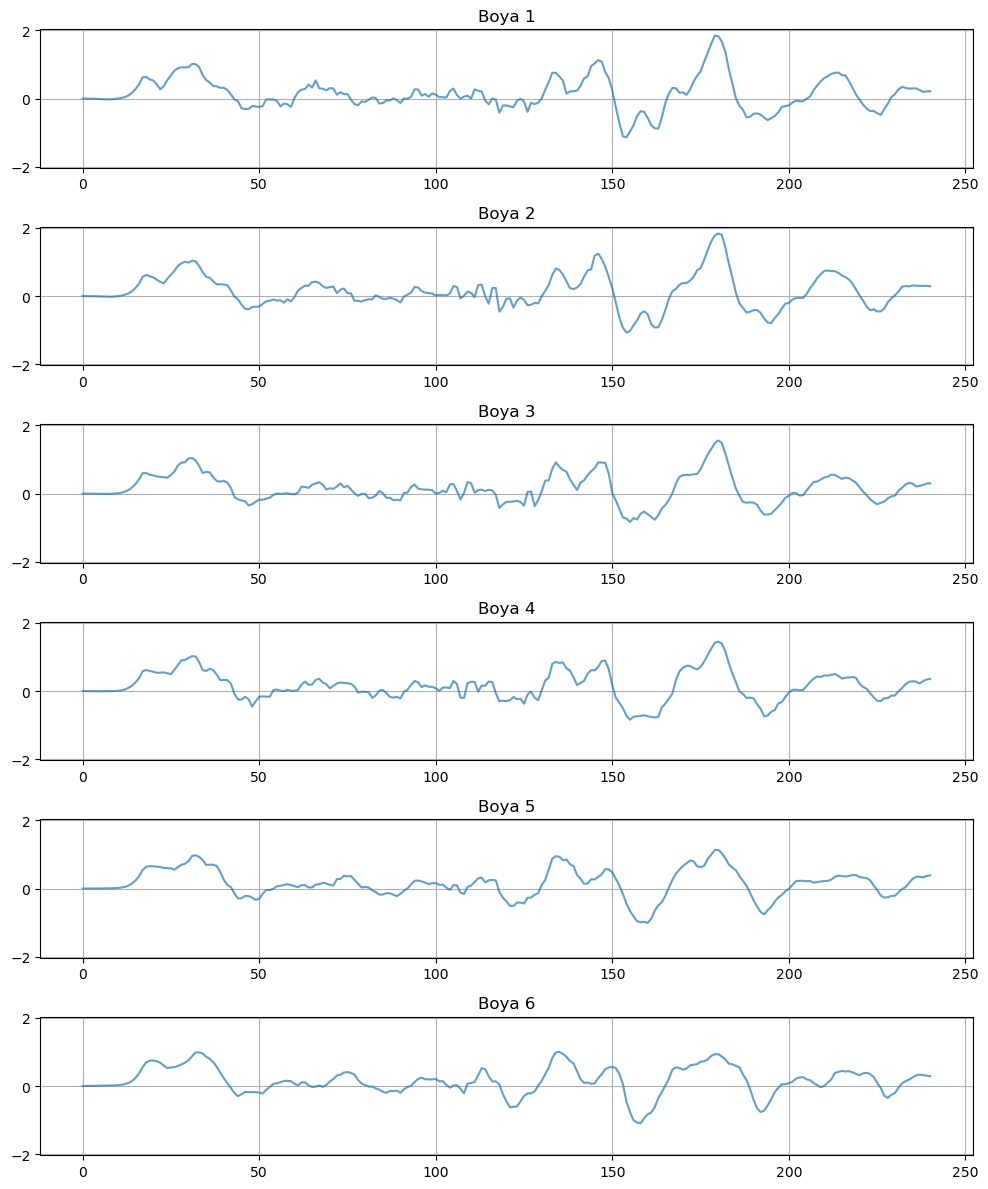

In [15]:
n_steps, features = X_nuevo.shape

y_lims = np.abs(X_nuevo).max()*1.1

fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    axes[i].plot(X_nuevo[:, i], alpha=0.7)
    #axes[i].plot(x_p90[:, i], alpha=0.7)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
    axes[i].grid()
    #axes[i].legend()
plt.tight_layout()
plt.show()

## Segmentation with bins of matrix profile distance

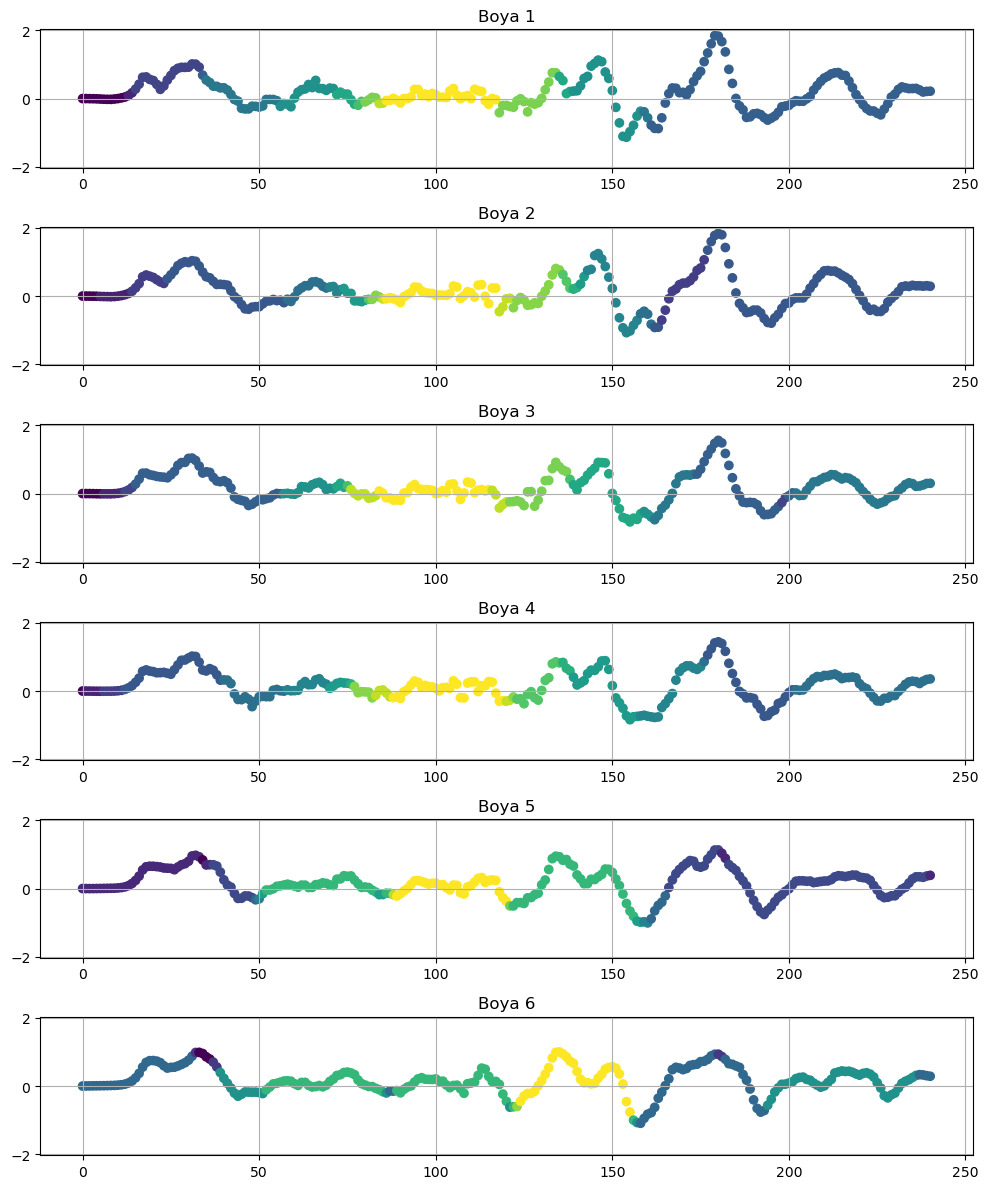

In [31]:
y_lims = np.abs(X_nuevo).max()*1.1

seg_method = 'bins-max'
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    seg_m = mseg.segment(X_nuevo[:, i].reshape(-1, 1), segmentation_method=seg_method)
    axes[i].scatter(range(n), X_nuevo[:, i], c=seg_m)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
    axes[i].grid()
    #axes[i].legend()
plt.tight_layout()
plt.show()

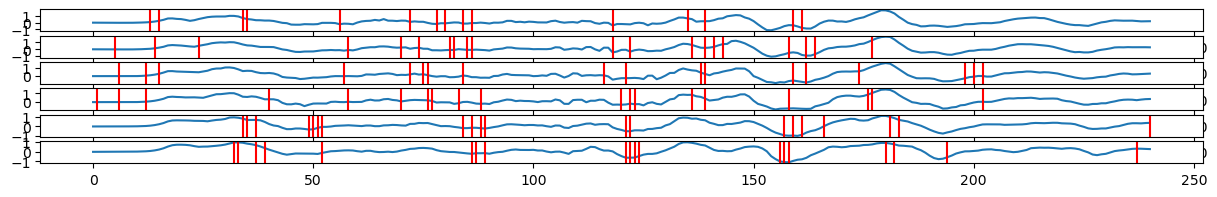

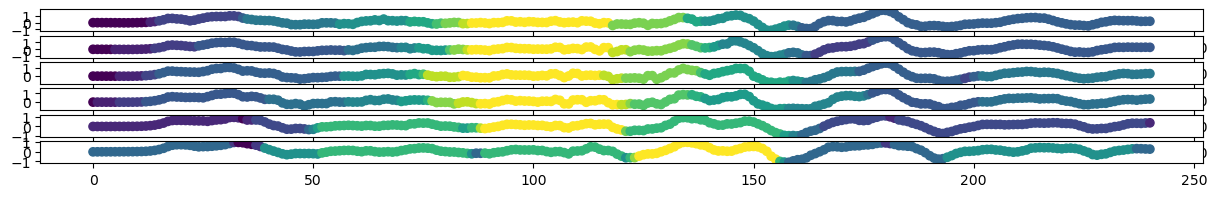

In [33]:
seg_m = mseg.segment(X_nuevo, segmentation_method='bins-max')

visualize_segmentation_mask(X_nuevo, seg_m)

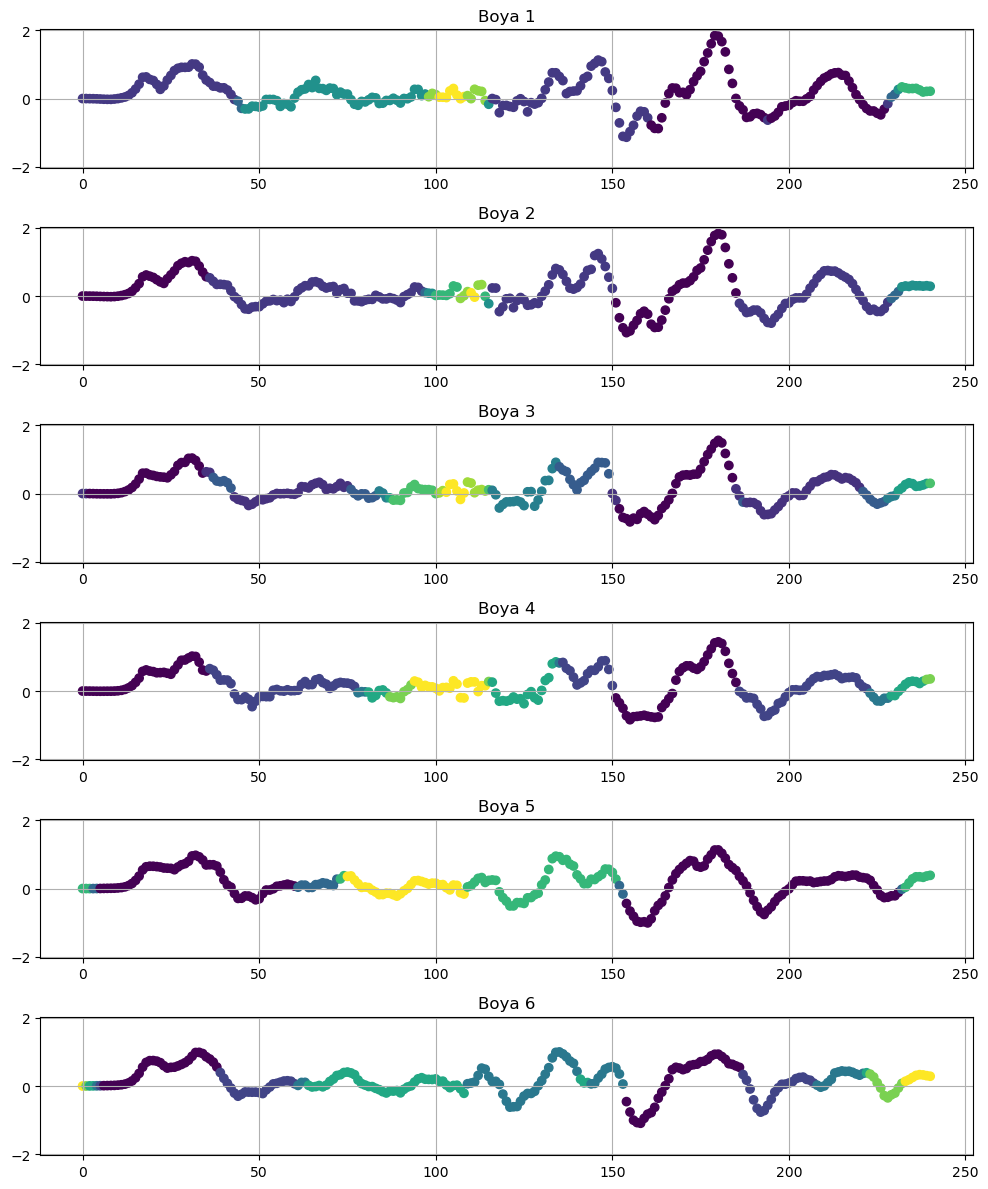

In [32]:
seg_method = 'bins-min'
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    seg_m = mseg.segment(X_nuevo[:, i].reshape(-1, 1), segmentation_method=seg_method)
    axes[i].scatter(range(n), X_nuevo[:, i], c=seg_m)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
    axes[i].grid()
    #axes[i].legend()
plt.tight_layout()
plt.show()

-

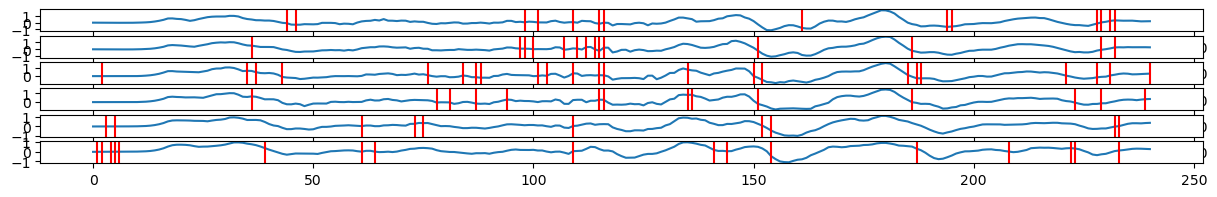

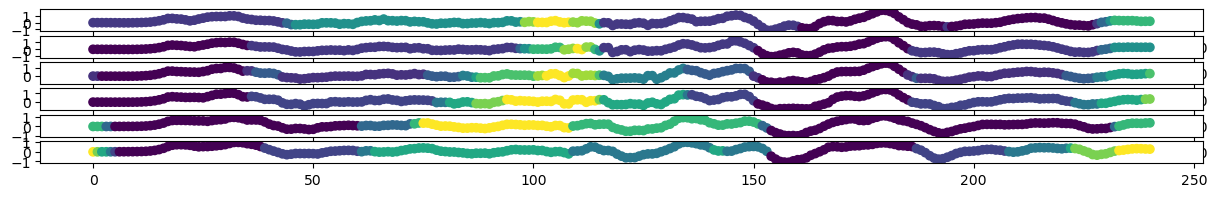

In [34]:
seg_m = mseg.segment(X_nuevo, segmentation_method='bins-min')

visualize_segmentation_mask(X_nuevo, seg_m)

## Segmentation with slopes of matrix profile distance

In [35]:
mseg = MatrixProfileSegmentation(partitions=15, win_length=32)

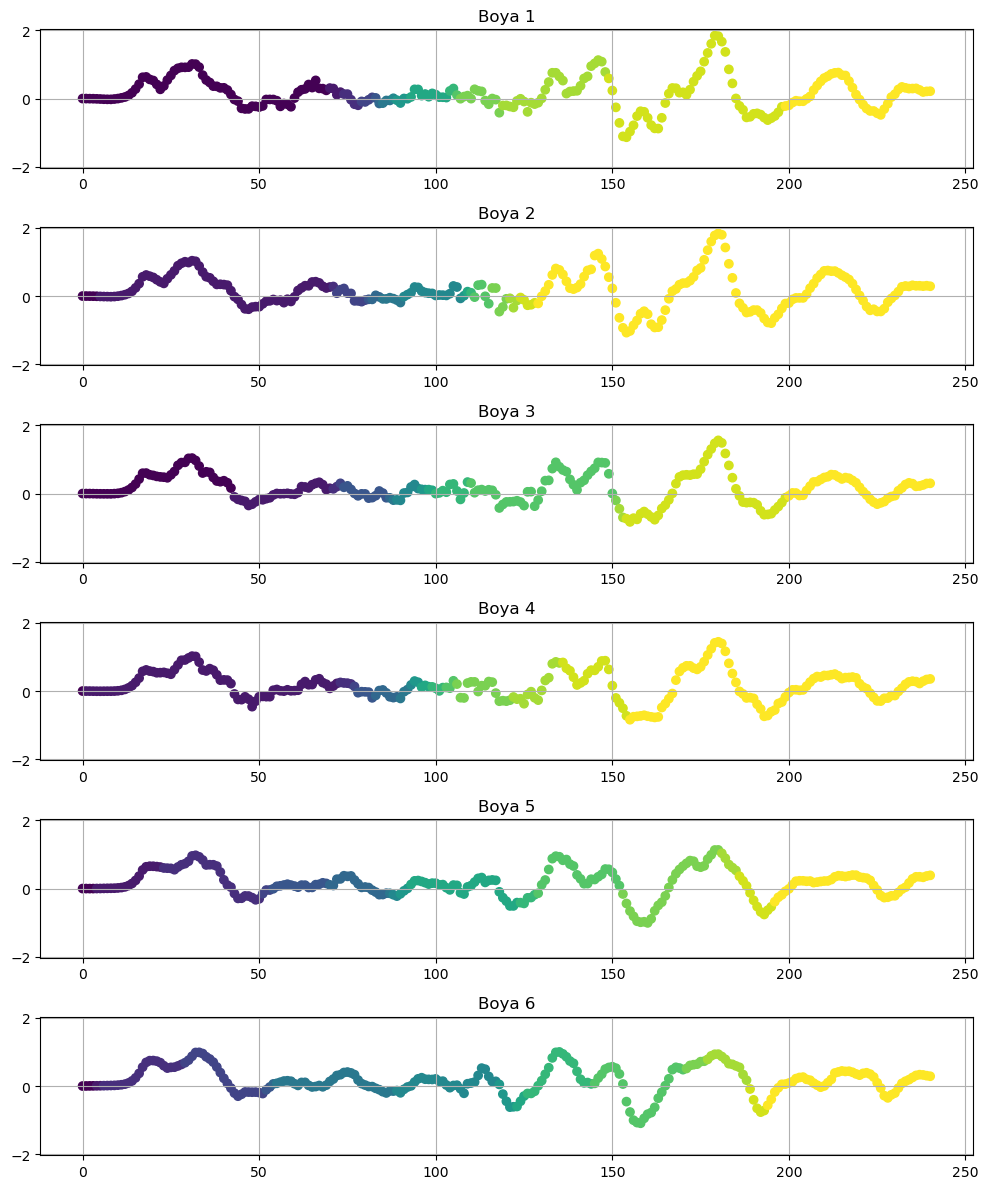

In [36]:
seg_method = 'slopes-sorted'
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    seg_m = mseg.segment(X_nuevo[:, i].reshape(-1, 1), segmentation_method=seg_method)
    axes[i].scatter(range(n), X_nuevo[:, i], c=seg_m)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
    axes[i].grid()
    #axes[i].legend()
plt.tight_layout()
plt.show()

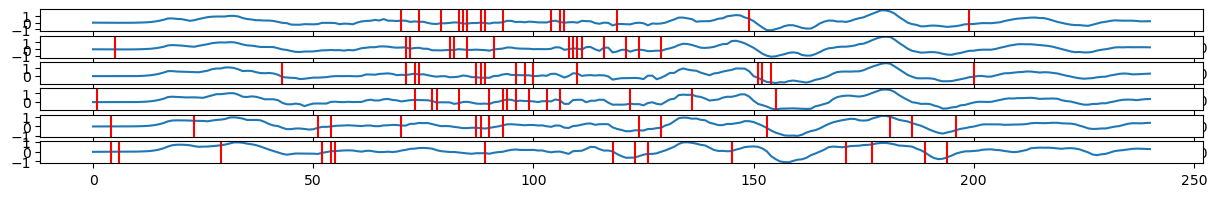

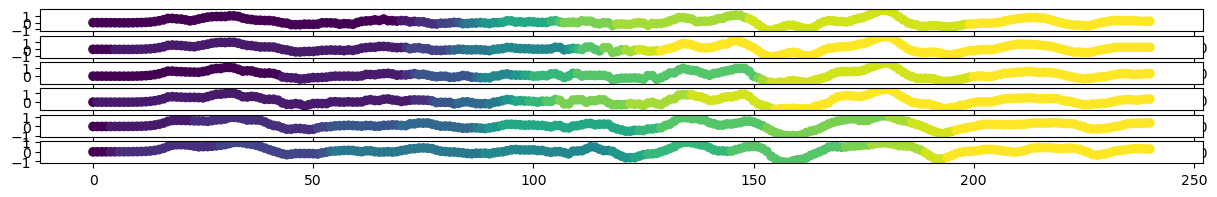

In [37]:
seg_m = mseg.segment(X_nuevo, segmentation_method='slopes-sorted')

visualize_segmentation_mask(X_nuevo, seg_m)

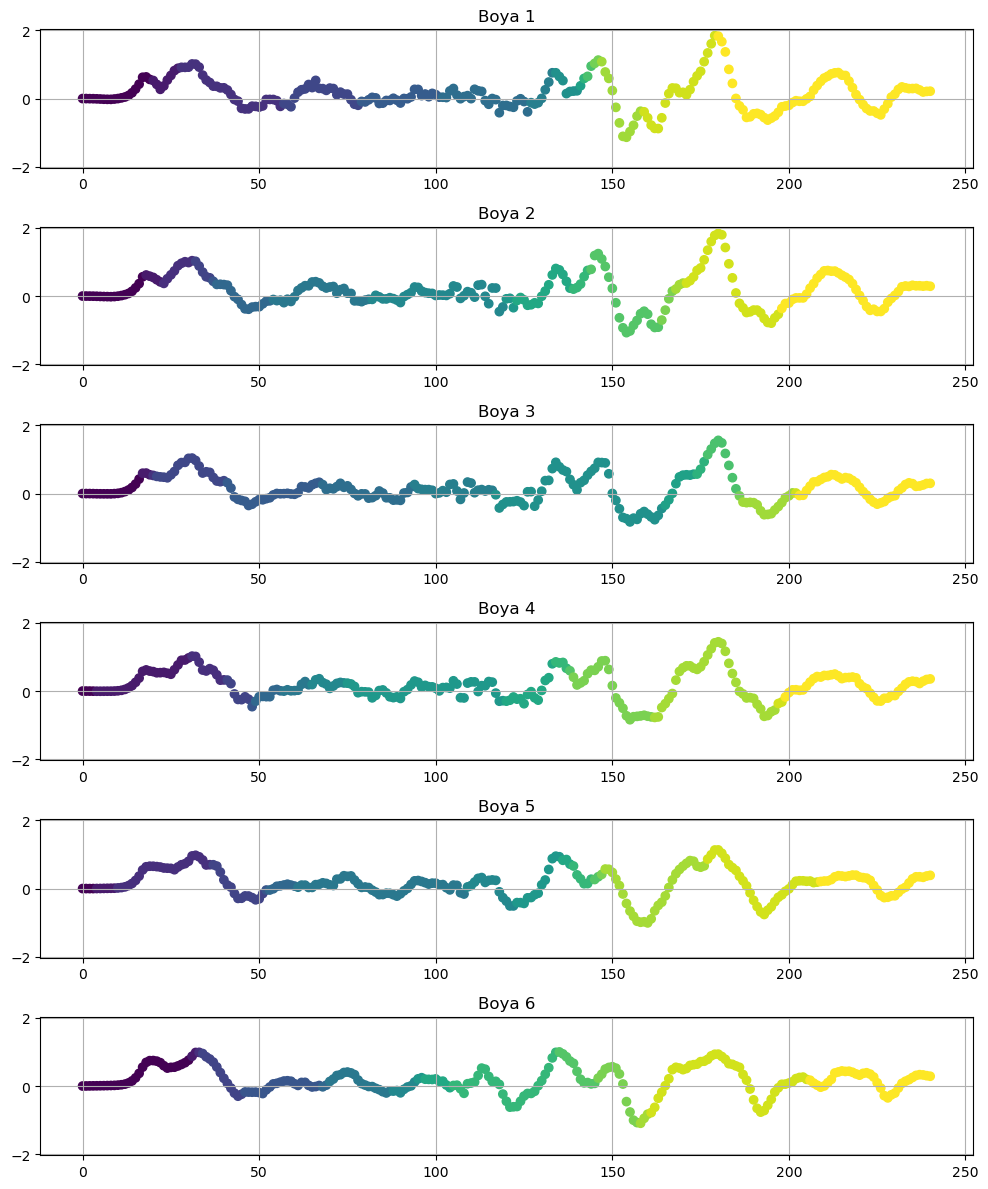

In [38]:
#seg_m = mseg.segment(mts, segmentation_method='slopes-not-sorted')
seg_method = 'slopes-not-sorted'
fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
for i in range(features):
    seg_m = mseg.segment(X_nuevo[:, i].reshape(-1, 1), segmentation_method=seg_method)
    axes[i].scatter(range(n), X_nuevo[:, i], c=seg_m)
    axes[i].set_title(f'Boya {i+1}')
    axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
    axes[i].grid()
    #axes[i].legend()
plt.tight_layout()
plt.show()

## Segmentation with SAX

In [32]:
sseg = SAXSegmentation(partitions=15, win_length=32)

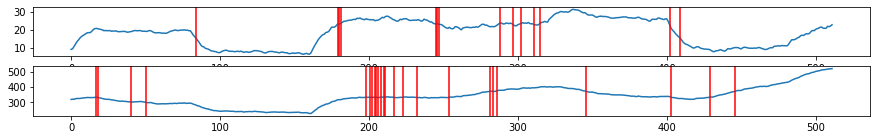

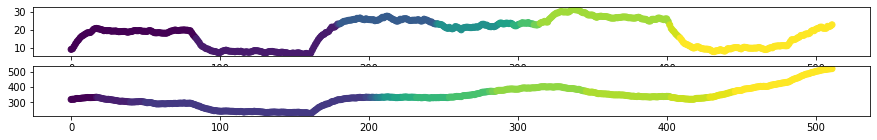

In [33]:
seg_m = sseg.segment(mts)

visualize_segmentation_mask(mts, seg_m)

# Segmentation with uniform and exponential windows

In [40]:
wseg = WindowSegmentation(partitions=15, win_length=32)

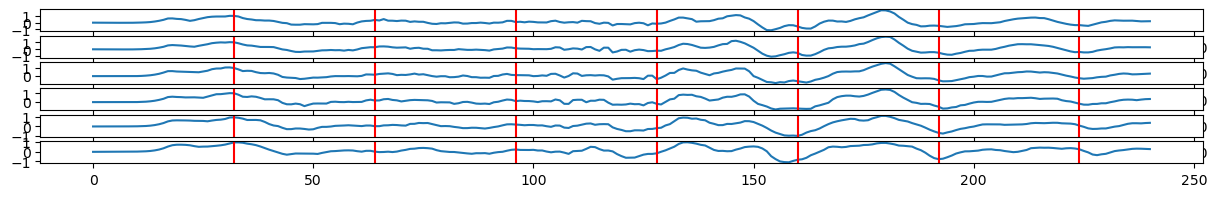

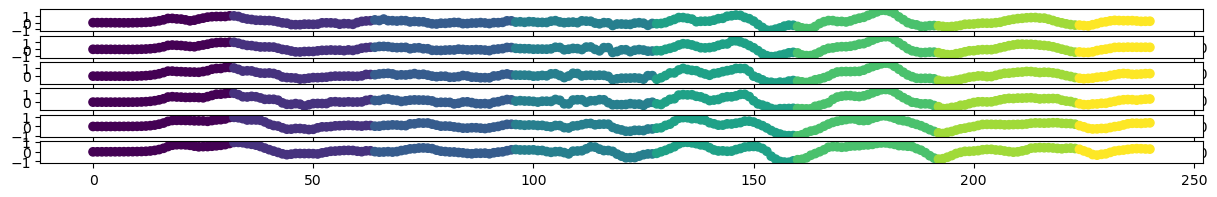

In [41]:
seg_m = wseg.segment(X_nuevo)

visualize_segmentation_mask(X_nuevo, seg_m)

# seg_method = 'slopes-not-sorted'
# fig, axes = plt.subplots(features, 1, figsize=(10, features*2))
# for i in range(features):
#     seg_m = mseg.segment(X_nuevo[:, i].reshape(-1, 1), segmentation_method=seg_method)
#     axes[i].scatter(range(n), X_nuevo[:, i], c=seg_m)
#     axes[i].set_title(f'Boya {i+1}')
#     axes[i].set_ylim([-y_lims, y_lims]) #Normalizamos eje y
#     axes[i].grid()
#     #axes[i].legend()
# plt.tight_layout()
# plt.show()

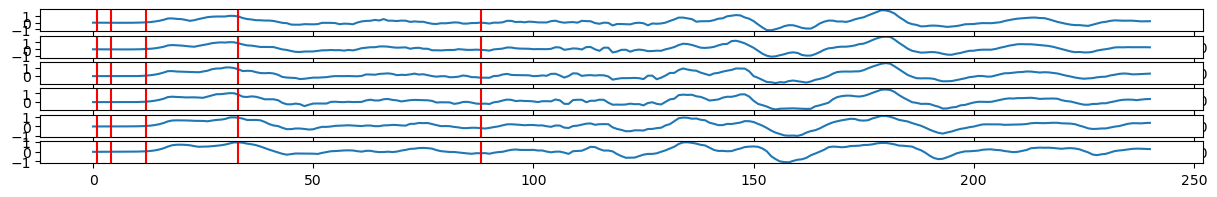

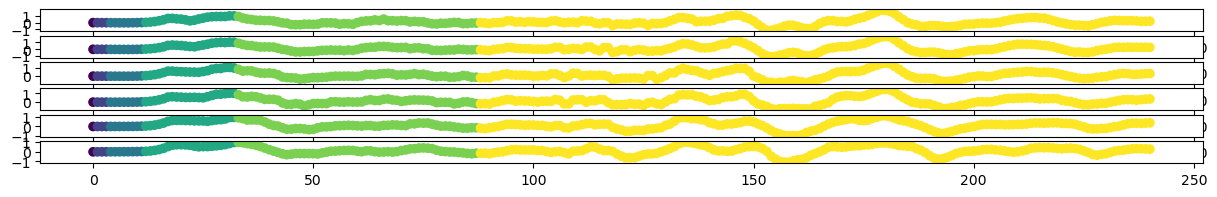

In [42]:
seg_m = wseg.segment(X_nuevo, 'exponential')

visualize_segmentation_mask(X_nuevo, seg_m)

# Single image

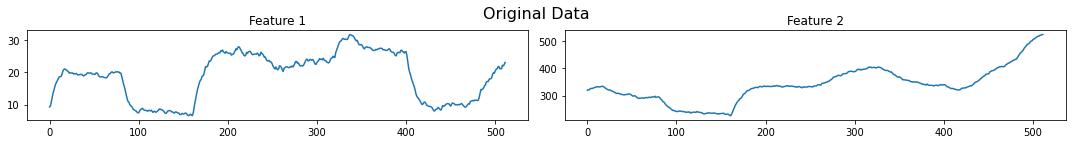

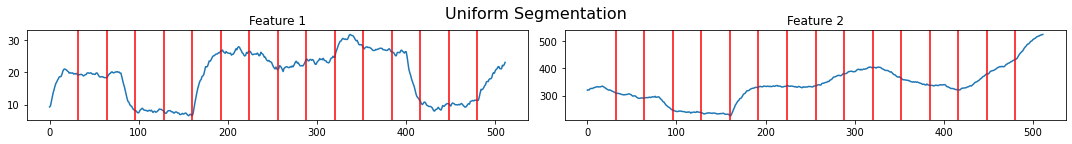

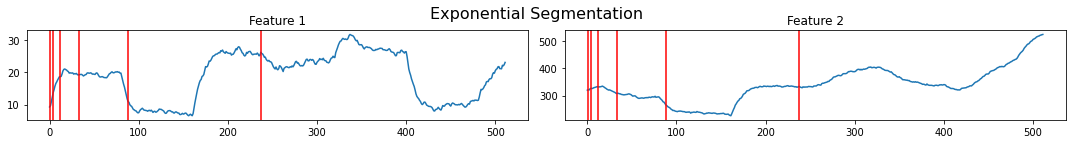

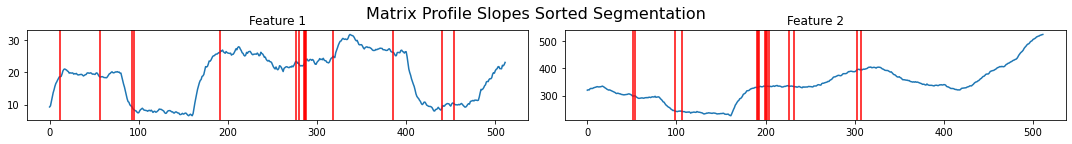

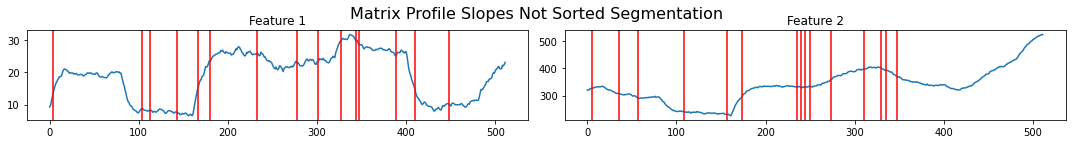

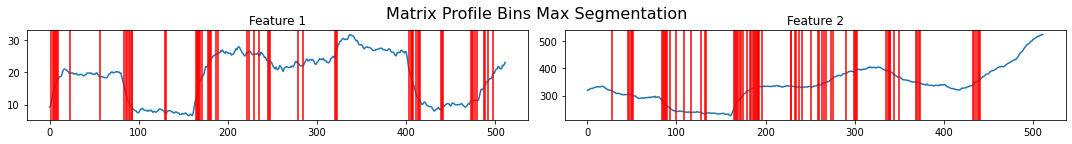

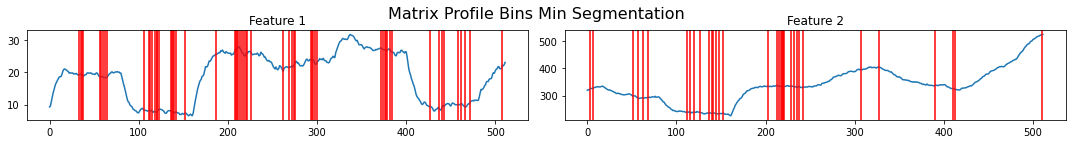

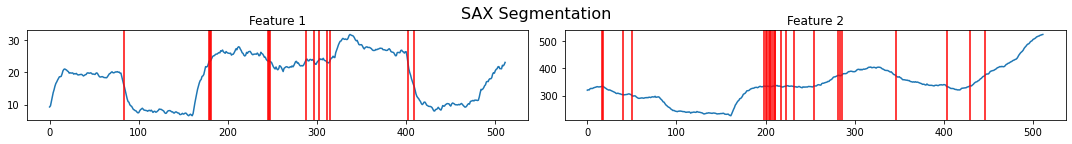

In [38]:
mseg = MatrixProfileSegmentation(partitions=15, win_length=32)
seg_bins_max = mseg.segment(mts, segmentation_method='bins-max')
seg_bins_min = mseg.segment(mts, segmentation_method='bins-min')

mseg = MatrixProfileSegmentation(partitions=15, win_length=32)
seg_slopes_sorted = mseg.segment(mts, segmentation_method='slopes-sorted')
seg_slopes_not_sorted = mseg.segment(mts, segmentation_method='slopes-not-sorted')

sseg = SAXSegmentation(partitions=15, win_length=32)
seg_sax = sseg.segment(mts)

wseg = WindowSegmentation(partitions=15, win_length=32)
seg_uniform = wseg.segment(mts)
seg_exponential = wseg.segment(mts, 'exponential')

n_steps, n_features = mts.shape

fig, ax = plt.subplots(1, 2)

ax[0].plot(mts[:, 0])
ax[0].set_title('Feature 1')
ax[1].plot(mts[:, 1])
ax[1].set_title('Feature 2')

fig.tight_layout()
fig.suptitle('Original Data', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_uniform[0, 0]
for j in range(n_steps):
    value = seg_uniform[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_uniform[0, 1]
for j in range(n_steps):
    value = seg_uniform[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Uniform Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_exponential[0, 0]
for j in range(n_steps):
    value = seg_exponential[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_exponential[0, 1]
for j in range(n_steps):
    value = seg_exponential[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Exponential Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_slopes_sorted[0, 0]
for j in range(n_steps):
    value = seg_slopes_sorted[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_slopes_sorted[0, 1]
for j in range(n_steps):
    value = seg_slopes_sorted[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Matrix Profile Slopes Sorted Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_slopes_not_sorted[0, 0]
for j in range(n_steps):
    value = seg_slopes_not_sorted[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_slopes_not_sorted[0, 1]
for j in range(n_steps):
    value = seg_slopes_not_sorted[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Matrix Profile Slopes Not Sorted Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_bins_max[0, 0]
for j in range(n_steps):
    value = seg_bins_max[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_bins_max[0, 1]
for j in range(n_steps):
    value = seg_bins_max[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Matrix Profile Bins Max Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_bins_min[0, 0]
for j in range(n_steps):
    value = seg_bins_min[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_bins_min[0, 1]
for j in range(n_steps):
    value = seg_bins_min[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('Matrix Profile Bins Min Segmentation', fontsize=16)
plt.show()

fig, ax = plt.subplots(1, 2)

ax[0].set_title('Feature 1')
ax[0].plot(mts[:, 0])
old_value = seg_sax[0, 0]
for j in range(n_steps):
    value = seg_sax[j, 0]
    if old_value != value:
        ax[0].axvline(x=j, color='red')
        old_value = value
        
ax[1].set_title('Feature 2')
ax[1].plot(mts[:, 1])
old_value = seg_sax[0, 1]
for j in range(n_steps):
    value = seg_sax[j, 1]
    if old_value != value:
        ax[1].axvline(x=j, color='red')
        old_value = value

fig.tight_layout()
fig.suptitle('SAX Segmentation', fontsize=16)
plt.show()

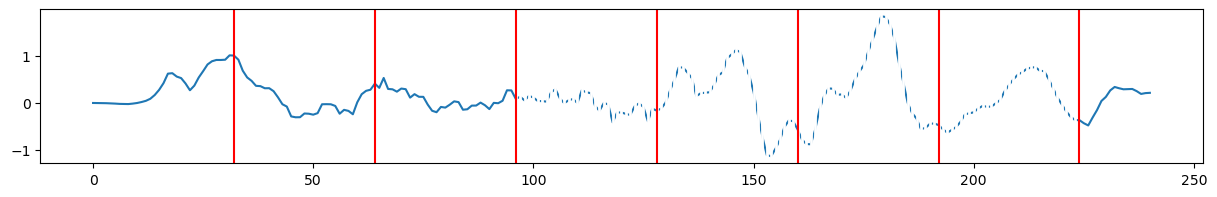

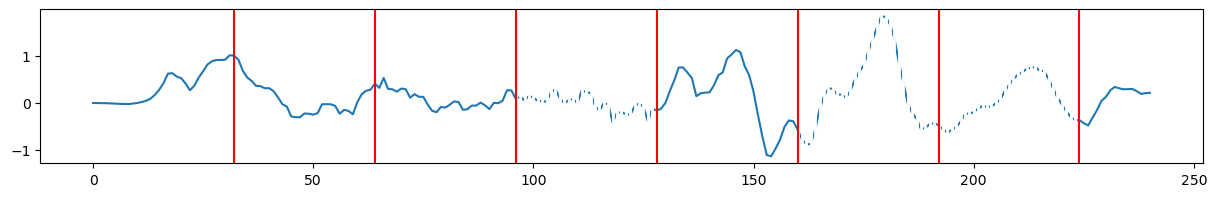

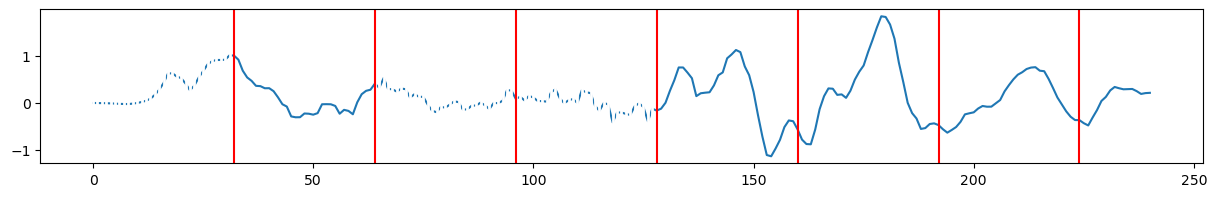

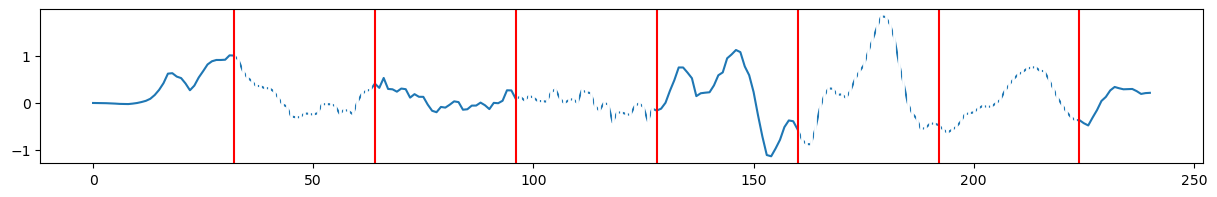

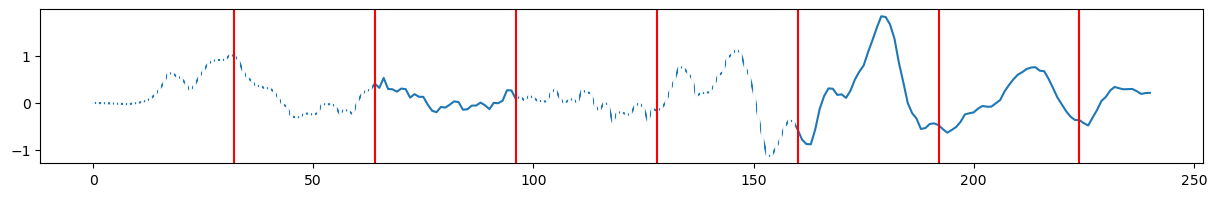

In [44]:
wseg = WindowSegmentation(partitions=15, win_length=32)
seg_uniform = wseg.segment(X_nuevo)

for i in range(5):
    rand_idx = np.random.choice(seg_uniform[:, 0], int(len(np.unique(seg_uniform[:, 0])) / 2))

    plt.plot(X_nuevo[:, 0])
    old_value = seg_uniform[0, 0]
    for j in range(n_steps):
        value = seg_uniform[j, 0]

        if value in list(rand_idx):
            plt.axvline(x=j, linewidth=2, color='w')

        if old_value != value:
            plt.axvline(x=j, color='red')
            old_value = value
    
    plt.show()


# Lo que muestra el gráfico
# Para cada una de las 5 iteraciones aleatorias:

# Línea azul → la señal de la primera boya (X_nuevo[:, 0])
# Líneas rojas → fronteras entre segmentos consecutivos (dónde termina un segmento y empieza otro)
# Líneas blancas → segmentos seleccionados aleatoriamente para ser "apagados" — simula lo que haría LIME al perturbar esa muestra

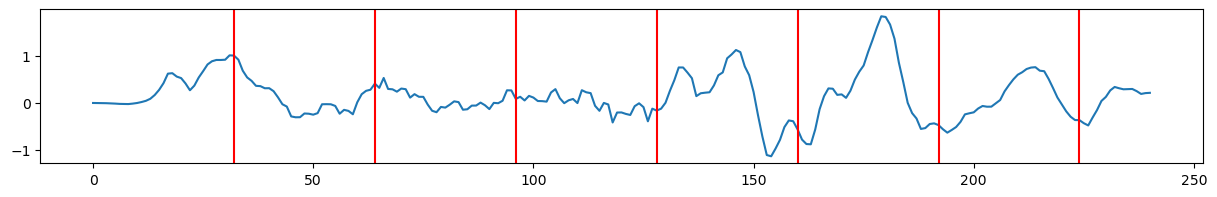

In [45]:
plt.plot(X_nuevo[:, 0])
old_value = seg_uniform[0, 0]
for j in range(n_steps):
    value = seg_uniform[j, 0]
    if old_value != value:
        plt.axvline(x=j, color='red')
        old_value = value
    
plt.show()

In [47]:
# np.random.random(len(np.unique(seg_uniform[:, 0])))

In [48]:
# plt.get_cmap('Reds')(0.5)

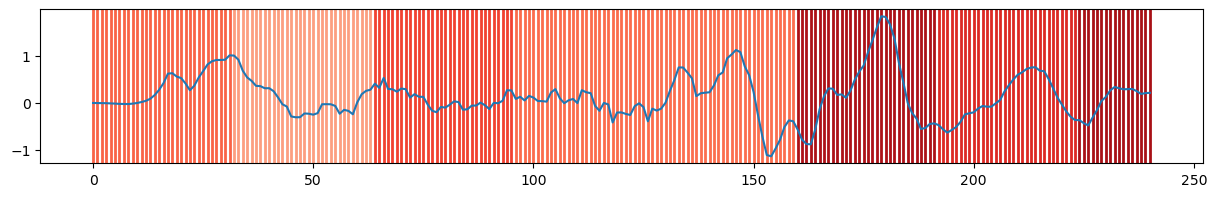

In [50]:
col = np.random.random(len(np.unique(seg_uniform[:, 0])))

old_value = seg_uniform[0, 0]
i = 0
for j in range(n_steps):
    value = seg_uniform[j, 0]
    if old_value != value:
        old_value = value
        i += 1
    plt.axvline(x=j, linewidth=2, color=plt.get_cmap('Reds')(col[i]))


plt.plot(X_nuevo[:, 0])
plt.show()